# Introduction: The Geometric Intuition"
"Stop thinking in formulas, start thinking in flows."

In traditional calculus, we are taught to solve $\dot{x} = f(x)$ by integrating to find $x(t)$. But for most complex systems, an analytical solution is impossible. Steven Strogatz argues that we should instead look at the Vector Field.

"We think of $t$ as time, $x$ as the position of an imaginary particle moving along the real line, and $\dot{x}$ as the velocity of that particle... The flow is to the right where $f(x) > 0$ and to the left where $f(x) < 0$." — Strogatz 

Fixed Points: The Anchors of Logic
- Attractors (Stable): Points where the flow converges. These represent "memories" or "steady states."
- Repellers (Unstable): Points where the flow pushes the state away. These represent "decision boundaries."

 # The Anatomy of Stability

## What is Stability?
In a dynamical system, a fixed point $x^*$ is stable if the system resists change. If you "nudge" the state slightly away from ^*$, the physics of the system should force it back.

## Method 1: The Graphical Intuition (The "Velocity" View)
In 1D, $\dot{x} = f(x)$ means the graph of f(x) is a Velocity Map.

**The Nudge:** Imagine a fixed point at $x^*$.
- **Nudge Right ( x > $x^*$): If the graph of f(x) is below the x-axis (negative velocity), the particle is pushed back to the Left toward $x^*$.
- **Nudge Left ( x < $x^*$): If the graph of f(x) is above the x-axis (positive velocity), the particle is pushed back to the Right toward $x^*$.

**The Condition:** 
For the arrows to point "inward" from both sides, the function (x) must cross the x-axis from positive to negative. This is why a negative slope at the fixed point f(x^*) < 0 guarantees stability.

## Method 2: Linear Stability Analysis (The "Eigenvalue" View)
Let (t) = x(t) - $x^*$ be a tiny perturbation. As we derived in our derivations.md:

$$
\dot{u} \approx f'(x^*)u
$$
The solution is $u(t) = u(0)e^{f'(x^*)t}$.
In 1D, the Jacobian Matrix is just the scalar $J = [f'(x^*)]$.
The Eigenvalue $\lambda$ of this Jacobian is simply $f'(x^*)$.The Math of Decay: If $\lambda < 0$, the term $e^{\lambda t}$ represents exponential decay. The "error" $u(t)$ vanishes over time.


# Case Study: The Logistic Equation
 
## The Model
 
The Logistic Equation is defined as:
 
$$\dot{x} = rx \left(1 - \frac{x}{K}\right)$$
 
Setting growth rate $r = 1$ and carrying capacity $K = 1$, we get the simplified form:
 
$$\dot{x} = x(1 - x)$$
 
---
 
## Linear Stability Analysis
 
A small perturbation $u$ away from a fixed point $x^*$ evolves according to:
 
$$\dot{u} = f'(x^*)\, u$$
 
For $x^* = 1$: $\quad f'(1) = -1$
 
Since the slope is **negative**, the perturbation decays. **Prediction: $x = 1$ is a stable attractor.**
 
---
 
## Manual Implementation: The Euler Engine
 
The Euler method is the simplest way to simulate time — take the current position, calculate the velocity, and move a small step in that direction.
 
$$x_{n+1} = x_n + f(x_n)\,\Delta t$$

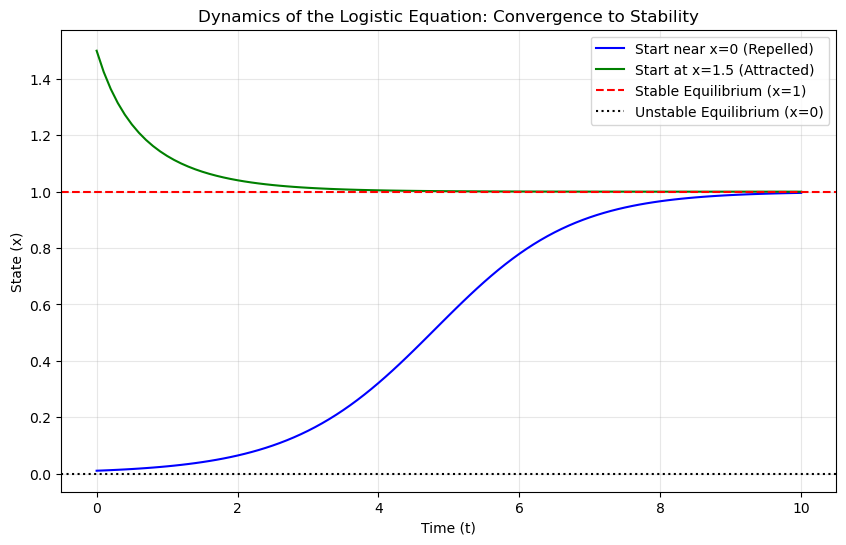

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def logistic_flow(x):
    """The velocity function f(x) = x(1 - x)"""
    return x * (1 - x)

def euler_solve(flow_func, x0, dt, total_time):
    # Calculate total number of steps
    steps = int(total_time / dt)
    
    # Initialize history with the starting point
    x_history = [x0]
    current_x = x0
    
    for i in range(steps):
        # 1. Calculate the velocity (v) at the current_x
        v = flow_func(current_x)
        
        # 2. Update current_x: new_x = old_x + velocity * dt
        current_x = current_x + v * dt
        
        # 3. Append the new state to our history
        x_history.append(current_x)
        
    return np.array(x_history)

# --- Simulation and Visualization ---
x0_unstable = 0.01  # Start near the unstable point x=0
x0_above = 1.5      # Start above the stable point x=1

dt = 0.1
T = 10

traj1 = euler_solve(logistic_flow, x0_unstable, dt, T)
traj2 = euler_solve(logistic_flow, x0_above, dt, T)

# Plotting the "Convergence to Stability"
plt.figure(figsize=(10, 6))
t_axis = np.linspace(0, T, len(traj1))

plt.plot(t_axis, traj1, label="Start near x=0 (Repelled)", color='blue')
plt.plot(t_axis, traj2, label="Start at x=1.5 (Attracted)", color='green')
plt.axhline(1, color='red', linestyle='--', label="Stable Equilibrium (x=1)")
plt.axhline(0, color='black', linestyle=':', label="Unstable Equilibrium (x=0)")

plt.title("Dynamics of the Logistic Equation: Convergence to Stability")
plt.xlabel("Time (t)")
plt.ylabel("State (x)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()